## Two interacting magnets

## Experiment 1: Use Sampler to measure the state


#### 1. Map

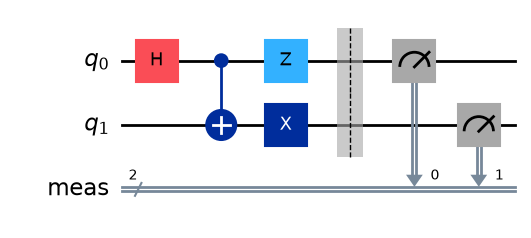

In [12]:
# Import IBM Quantum primitives
from qiskit import QuantumCircuit

# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

# Measure state
qc.measure_all()

# Draw circuit
qc.draw("mpl")

#### 2. Optimize

In [13]:
# Load IBM Quantum Compute Service
from qiskit_ibm_runtime import QiskitRuntimeService

## Load IBM Quantum Compute Service
# QiskitRuntimeService.save_account(
#    channel="ibm_quantum_platform",
#    token="YOUR_TOKEN_HERE",
#    overwrite=True,
#    set_as_default=True,
# )
# service = QiskitRuntimeService(channel="ibm_quantum_platform")


# Or load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_brisbane")
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-09-04 13:43:38,742: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: surnandi. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-04 13:43:39,372: Loading instance: surnandi, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-04 13:43:42,772: Using instance: surnandi, plan: open


ibm_marrakesh


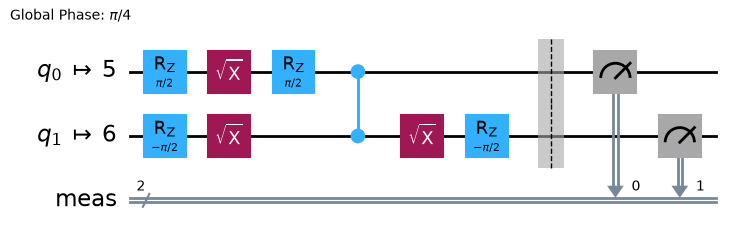

In [14]:
# Transpile the circuit and optimize for running on the quantum computer selected
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

#### 3. Execute

In [15]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

In [22]:
# Load the backend sampler
from qiskit.primitives import BackendSamplerV2
from qiskit.providers.fake_provider import GenericBackendV2

# # Load the Aer simulator and generate a noise model based on the currently-selected backend.
# from qiskit_aer import AerSimulator
# from qiskit_aer.noise import NoiseModel

# noise_model = NoiseModel.from_backend(backend)

# # Define a simulator using Aer, and use it in Sampler.
# backend_sim = AerSimulator(noise_model=noise_model)
# sampler_sim = BackendSamplerV2(backend=backend_sim)

# Alternatively, load a fake backend with generic properties and define a simulator.
backend_gen = GenericBackendV2(num_qubits=18)
sampler_gen = BackendSamplerV2(backend=backend_gen)

In [23]:
job = sampler.run([qc_isa], shots=100)
# job = sampler_sim.run([qc_isa]) # uncomment if you want to run on a simulator
res = job.result()
counts = res[0].data.meas.get_counts()

#### 4. Post-process

counts =  {'10': 49, '01': 50, '00': 1}


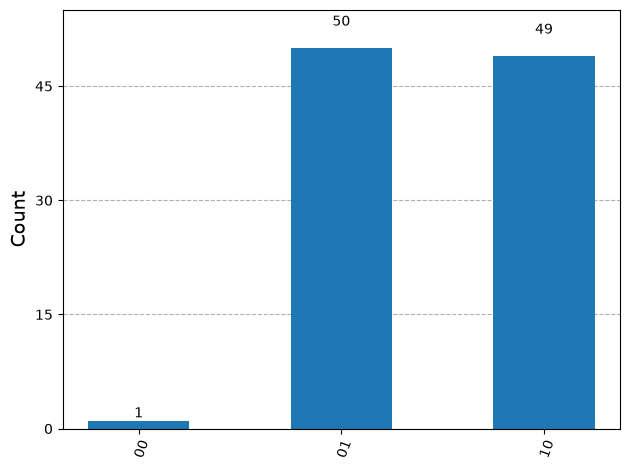

In [ ]:
from qiskit.visualization import plot_histogram

print("counts = ", counts)
plot_histogram(counts)

## Experiment 2: Use Estimator to measure the energy

#### 1. Map

In [24]:
# Import IBM Quantum primitives
from qiskit.quantum_info import SparsePauliOp

# Parameters
J = 1.0  # antiferromagnetic coupling (J>0)
hx = -0.5  # transverse field strength

# 1. Define the Hamiltonian H = J Z1 Z2 + hx (X1 + X2)
obs = SparsePauliOp.from_list([("ZZ", J), ("XI", hx), ("IX", hx)])

# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

#### 2. Optimize

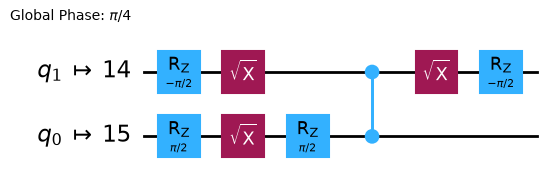

In [25]:
# Transpile the circuit and optimize for running on the quantum computer selected
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

qc_isa.draw("mpl")

#### 3. Execute

In [26]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [27]:
# Load the backend sampler

# noise_model = NoiseModel.from_backend(backend)

# Use Aer simulator in Estimator
# estimator_sim = BackendEstimatorV2(backend=backend_sim)

# Alternatively, load a fake backend with generic properties and define a simulator.
# backend_gen = GenericBackendV2(num_qubits=18)
# estimator_gen = BackendEstimatorV2(backend=backend_gen)

In [28]:
pubs = [(qc_isa, obs_isa)]
job = estimator.run([[qc_isa, obs_isa]])
res = job.result()

# Uncomment lines below to run the job on the Aer simulator with noise model from real backend
# job = estimator_sim.run([[qc_isa,obs_isa]])
# res=job.result()

#### 4. Post-process

In [29]:
print(res[0].data.evs)

-0.9864900247530509
